# Final Load vs. Jamming State Comparison

This notebook compares the final-load graph list against the jamming graph list after relabeling jamming high-force contacts with the final-load `0deg` threshold.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

ROOT = Path("/scratch/abucsek_root/abucsek0/yfjin/Granular_RubySim")
FINAL_DIR = ROOT / "AnalysisResults/FinalLoadState/FullGraph_2mean_ref_geom"
JAMMING_DIR = ROOT / "AnalysisResults/JammingState/FullGraph_final_load_threshold"
COMPARE_DIR = ROOT / "AnalysisResults/LoadStateComparison/Final_vs_Jamming_final_threshold"
PLOT_DIR = COMPARE_DIR / "Plots"
COMPARE_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

GEOM_ORDER = ["0deg", "15deg", "30deg", "45deg"]
GEOM_LABELS = ["0°", "15°", "30°", "45°"]
GROUP_COLORS = {
    "all": "#00274C",
    "final_hf_cluster": "#E67E22",
    "final_non_hf_cluster": "#0DAE70",
}
GROUP_LABELS = {
    "all": "All nodes",
    "final_hf_cluster": "Final high-force cluster nodes",
    "final_non_hf_cluster": "Final non-high-force-cluster nodes",
}

FINAL_DIR, JAMMING_DIR, COMPARE_DIR

(PosixPath('/scratch/abucsek_root/abucsek0/yfjin/Granular_RubySim/AnalysisResults/FinalLoadState/FullGraph_2mean_ref_geom'),
 PosixPath('/scratch/abucsek_root/abucsek0/yfjin/Granular_RubySim/AnalysisResults/JammingState/FullGraph_final_load_threshold'),
 PosixPath('/scratch/abucsek_root/abucsek0/yfjin/Granular_RubySim/AnalysisResults/LoadStateComparison/Final_vs_Jamming_final_threshold'))

## 1. Threshold Check

In [3]:
import pickle

with open(FINAL_DIR / "high_force_threshold_info.pkl", "rb") as f:
    final_threshold_info = pickle.load(f)
with open(JAMMING_DIR / "high_force_threshold_info.pkl", "rb") as f:
    jamming_threshold_info = pickle.load(f)

final_threshold_info, jamming_threshold_info

({'mode': 'reference[0deg]', 'thresholds': {'0deg': 0.4200944651809045}},
 {'mode': 'external_reference[FinalLoadState/0deg]',
  'thresholds': {'0deg': 0.4200944651809045},
  'source': '/gpfs/accounts/abucsek_root/abucsek0/yfjin/Granular_RubySim/AnalysisResults/FinalLoadState/FullGraph_2mean_ref_geom'})

## 2. Regenerate Comparison Tables

In [3]:
import sys
sys.path.insert(0, str(ROOT / "AnalysisScripts/post_analysis"))
from compare_load_states import main as _compare_main

# Usually the CSVs already exist. Run this cell from a terminal if you need a full refresh:
# python /scratch/abucsek_root/abucsek0/yfjin/Granular_RubySim/AnalysisScripts/post_analysis/compare_load_states.py

## 3. Load Node-to-Node and Mean Changes

In [4]:
node_changes = pd.read_csv(COMPARE_DIR / "node_property_changes_long.csv")
node_mean_changes = pd.read_csv(COMPARE_DIR / "node_mean_property_changes.csv")
graph_changes = pd.read_csv(COMPARE_DIR / "graph_property_changes_wide.csv")

# Transfer final-state high-force CLUSTER node labels onto the node-to-node comparison table.
# This follows the existing analysis notebook convention: only hf_cluster_type == 1 is "cluster";
# isolated high-force contacts (type -100) are grouped with noncluster nodes.
final_cluster_labels = pd.read_csv(FINAL_DIR / "final_high_force_cluster_node_labels.csv")
final_cluster_labels = final_cluster_labels[
    [
        "geometry", "sim_idx", "node_id",
        "final_is_high_force_cluster_node",
        "final_hf_cluster_id", "final_hf_cluster_type",
        "final_is_force_chain_node", "final_high_force_degree",
    ]
]

node_changes = node_changes.merge(
    final_cluster_labels,
    on=["geometry", "sim_idx", "node_id"],
    how="left",
    validate="many_to_one",
)
if node_changes["final_is_high_force_cluster_node"].isna().any():
    missing = int(node_changes["final_is_high_force_cluster_node"].isna().sum())
    raise ValueError(f"Missing final-state cluster labels for {missing} comparison rows")

node_changes["final_cluster_group"] = np.where(
    node_changes["final_is_high_force_cluster_node"],
    "final_hf_cluster",
    "final_non_hf_cluster",
)

node_changes.head(), node_mean_changes.head(), graph_changes.head()

(  geometry  sim_idx  node_id feature   jamming     final  \
 0     0deg        0        0       x  0.000824  0.000829   
 1     0deg        0        1       x  0.000891  0.000890   
 2     0deg        0        2       x  0.000291  0.000298   
 3     0deg        0        3       x  0.000392  0.000392   
 4     0deg        0        4       x  0.000773  0.000769   
 
    delta_final_minus_jamming  relative_delta  \
 0               5.174112e-06        0.006278   
 1              -7.802893e-07       -0.000876   
 2               7.399529e-06        0.025463   
 3               4.535310e-07        0.001157   
 4              -3.247376e-06       -0.004203   
 
    final_is_high_force_cluster_node  final_hf_cluster_id  \
 0                             False                  NaN   
 1                             False                  NaN   
 2                             False                 33.0   
 3                             False                  NaN   
 4                             

## 4. Delta Summary by Final-State Cluster Node Group

For each feature and geometry, this table keeps the total average change and adds two group-specific columns: particles that are in high-force clusters in the final state and particles that are not. Final clusters use the same convention as the analysis notebook: `hf_cluster_type == 1`.

In [5]:
FEATURES = [
    "stress_vm", "stress_hydro", "stress_33",
    "degree", "closeness", "betweenness", "clustering",
    "avg_neighbor_degree", "avg_curvature_no_walls",
    "nfd", "nfd_r2", "high_force_degree",
]

# Total mean changes from the comparison script.
summary_all = (
    node_mean_changes
    .query("geometry != 'all' and feature in @FEATURES")
    [["geometry", "feature", "n_nodes", "mean_delta_final_minus_jamming", "median_delta_final_minus_jamming", "std_delta_final_minus_jamming"]]
    .assign(final_cluster_group="all")
)

# Group-specific mean changes from final-state high-force node labels.
summary_groups = (
    node_changes.query("feature in @FEATURES")
    .groupby(["geometry", "feature", "final_cluster_group"], dropna=False)
    .agg(
        n_nodes=("delta_final_minus_jamming", "size"),
        mean_delta_final_minus_jamming=("delta_final_minus_jamming", "mean"),
        median_delta_final_minus_jamming=("delta_final_minus_jamming", "median"),
        std_delta_final_minus_jamming=("delta_final_minus_jamming", "std"),
    )
    .reset_index()
)

grouped_delta_summary = pd.concat([summary_all, summary_groups], ignore_index=True)
grouped_delta_summary["stderr_delta_final_minus_jamming"] = (
    grouped_delta_summary["std_delta_final_minus_jamming"] / np.sqrt(grouped_delta_summary["n_nodes"])
)
grouped_delta_summary.to_csv(COMPARE_DIR / "node_delta_summary_by_final_cluster_group.csv", index=False)

# Wide view: one row per geometry/feature, one mean-delta column per group.
mean_delta_wide = (
    grouped_delta_summary
    .pivot_table(
        index=["geometry", "feature"],
        columns="final_cluster_group",
        values="mean_delta_final_minus_jamming",
    )
    .reset_index()
    .rename_axis(None, axis=1)
)
mean_delta_wide = mean_delta_wide[["geometry", "feature", "all", "final_hf_cluster", "final_non_hf_cluster"]]
mean_delta_wide.to_csv(COMPARE_DIR / "node_mean_delta_wide_by_final_cluster_group.csv", index=False)

# Final-state mean values using the same final-state cluster labels.
final_summary_all = (
    node_changes.query("feature in @FEATURES")
    .groupby(["geometry", "feature"], dropna=False)
    .agg(
        n_nodes=("final", "size"),
        mean_final=("final", "mean"),
        median_final=("final", "median"),
        std_final=("final", "std"),
    )
    .reset_index()
    .assign(final_cluster_group="all")
)

final_summary_groups = (
    node_changes.query("feature in @FEATURES")
    .groupby(["geometry", "feature", "final_cluster_group"], dropna=False)
    .agg(
        n_nodes=("final", "size"),
        mean_final=("final", "mean"),
        median_final=("final", "median"),
        std_final=("final", "std"),
    )
    .reset_index()
)

grouped_final_summary = pd.concat([final_summary_all, final_summary_groups], ignore_index=True)
grouped_final_summary["stderr_final"] = grouped_final_summary["std_final"] / np.sqrt(grouped_final_summary["n_nodes"])
grouped_final_summary.to_csv(COMPARE_DIR / "node_final_mean_summary_by_final_cluster_group.csv", index=False)

final_mean_wide = (
    grouped_final_summary
    .pivot_table(index=["geometry", "feature"], columns="final_cluster_group", values="mean_final")
    .reset_index()
    .rename_axis(None, axis=1)
)
final_mean_wide = final_mean_wide[["geometry", "feature", "all", "final_hf_cluster", "final_non_hf_cluster"]]
final_mean_wide.to_csv(COMPARE_DIR / "node_final_mean_wide_by_final_cluster_group.csv", index=False)

mean_delta_wide.sort_values(["feature", "geometry"])

,geometry,feature,all,final_hf_cluster,final_non_hf_cluster
0,0deg,avg_curvature_no_walls,0.094555,0.090559,0.096016
12,15deg,avg_curvature_no_walls,0.104737,0.104444,0.104829
24,30deg,avg_curvature_no_walls,0.089034,0.091501,0.088136
36,45deg,avg_curvature_no_walls,0.092093,0.097647,0.090194
1,0deg,avg_neighbor_degree,1.800509,1.709781,1.833671
13,15deg,avg_neighbor_degree,1.687548,1.612436,1.711125
25,30deg,avg_neighbor_degree,1.907746,1.908911,1.907322
37,45deg,avg_neighbor_degree,1.818130,1.837266,1.811585
2,0deg,betweenness,-0.000514,-0.001155,-0.000280
14,15deg,betweenness,-0.000723,-0.000861,-0.000680


## 5. Mean Final-State and Change Plots by Final-State Cluster Node Group

These plots show the final-state mean node properties and the mean node-property change (`final - jamming`) across geometry. They use the same groups: final high-force cluster nodes, final non-high-force-cluster nodes, and all nodes.

In [ ]:
MEAN_VALUE_GROUP_STYLES = {
    "final_hf_cluster": {"label": "Final HF cluster", "color": GROUP_COLORS["final_hf_cluster"], "marker": "^", "linestyle": "-"},
    "final_non_hf_cluster": {"label": "Final non-HF cluster", "color": GROUP_COLORS["final_non_hf_cluster"], "marker": "D", "linestyle": "--"},
    "all": {"label": "All nodes", "color": GROUP_COLORS["all"], "marker": "o", "linestyle": "-"},
}


def plot_final_mean_by_group(feature, save=True):
    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    x = np.arange(len(GEOM_ORDER))

    for group in ["final_hf_cluster", "final_non_hf_cluster", "all"]:
        style = MEAN_VALUE_GROUP_STYLES[group]
        sub = grouped_final_summary[
            (grouped_final_summary["feature"] == feature)
            & (grouped_final_summary["final_cluster_group"] == group)
        ]
        row = sub.set_index("geometry").reindex(GEOM_ORDER)
        ax.errorbar(
            x,
            row["mean_final"],
            yerr=row["stderr_final"],
            color=style["color"],
            marker=style["marker"],
            linestyle=style["linestyle"],
            linewidth=2.0,
            markersize=7,
            capsize=3,
            label=style["label"],
        )

    ax.set_xticks(x)
    ax.set_xticklabels(GEOM_LABELS)
    ax.set_xlabel("Boundary geometry")
    ax.set_ylabel(f"Final-state {feature}")
    ax.set_title(f"Final-state mean {feature}")
    ax.legend(frameon=False, fontsize=9)
    ax.grid(False)
    fig.tight_layout()
    if save:
        fig.savefig(PLOT_DIR / f"final_mean_{feature}_by_final_cluster_group.png", dpi=250, bbox_inches="tight")
    return fig, ax


for feature in FEATURES:
    plot_final_mean_by_group(feature)
    plt.show()


MEAN_CHANGE_GROUP_STYLES = {
    "final_hf_cluster": {"label": "Final HF cluster", "color": GROUP_COLORS["final_hf_cluster"], "marker": "^", "linestyle": "-"},
    "final_non_hf_cluster": {"label": "Final non-HF cluster", "color": GROUP_COLORS["final_non_hf_cluster"], "marker": "D", "linestyle": "--"},
    "all": {"label": "All nodes", "color": GROUP_COLORS["all"], "marker": "o", "linestyle": "-"},
}


def plot_mean_delta_by_group(feature, save=True):
    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    x = np.arange(len(GEOM_ORDER))

    for group in ["final_hf_cluster", "final_non_hf_cluster", "all"]:
        style = MEAN_CHANGE_GROUP_STYLES[group]
        sub = grouped_delta_summary[
            (grouped_delta_summary["feature"] == feature)
            & (grouped_delta_summary["final_cluster_group"] == group)
        ]
        row = sub.set_index("geometry").reindex(GEOM_ORDER)
        ax.errorbar(
            x,
            row["mean_delta_final_minus_jamming"],
            yerr=row["stderr_delta_final_minus_jamming"],
            color=style["color"],
            marker=style["marker"],
            linestyle=style["linestyle"],
            linewidth=2.0,
            markersize=7,
            capsize=3,
            label=style["label"],
        )

    y_limits = ax.get_ylim()
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylim(y_limits)
    ax.set_xticks(x)
    ax.set_xticklabels(GEOM_LABELS)
    ax.set_xlabel("Boundary geometry")
    ax.set_ylabel(f"Δ {feature} (final - jamming)")
    ax.set_title(f"Mean change in {feature}")
    ax.legend(frameon=False, fontsize=9)
    ax.grid(False)
    fig.tight_layout()
    if save:
        fig.savefig(PLOT_DIR / f"mean_delta_{feature}_by_final_cluster_group.png", dpi=250, bbox_inches="tight")
    return fig, ax


for feature in FEATURES:
    plot_mean_delta_by_group(feature)
    plt.show()

## 5. Delta Histograms by Final-State Cluster Node Group

Each panel shows the node-level distribution of `final - jamming` for one geometry. Gray is all nodes, orange is final high-force cluster nodes, and green is final non-high-force-cluster nodes. Dashed vertical lines mark each group mean.

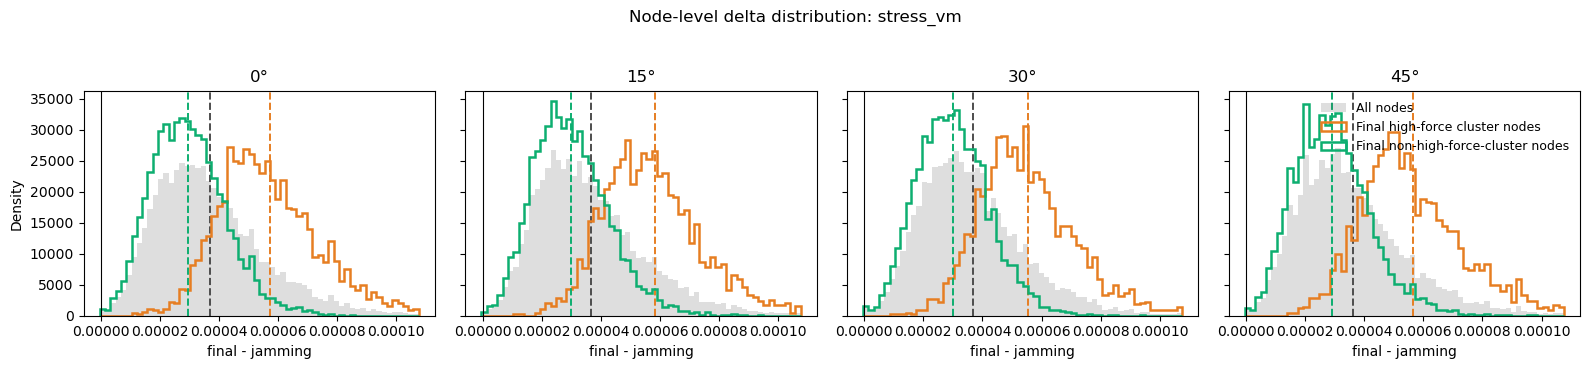

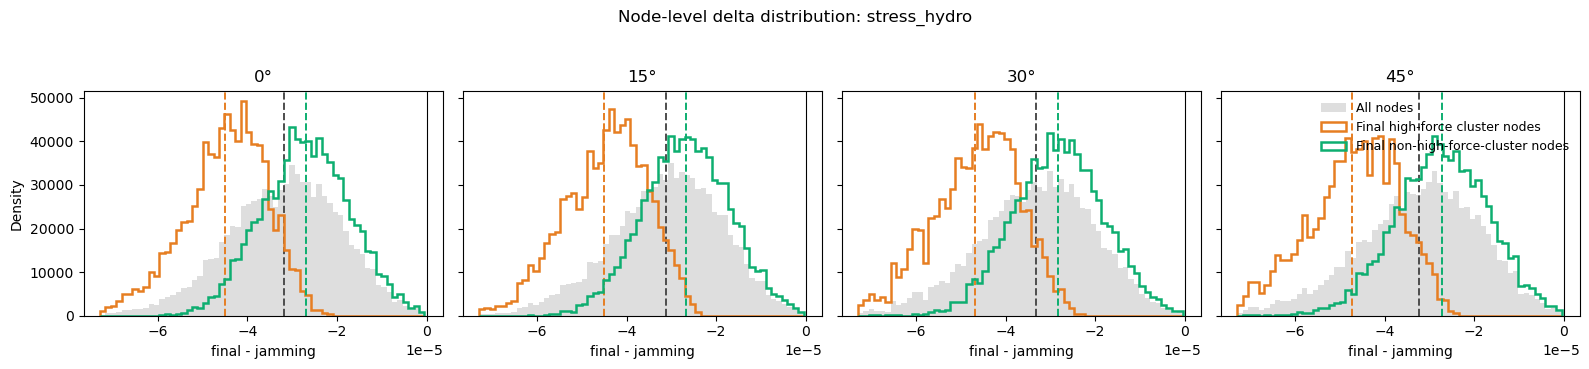

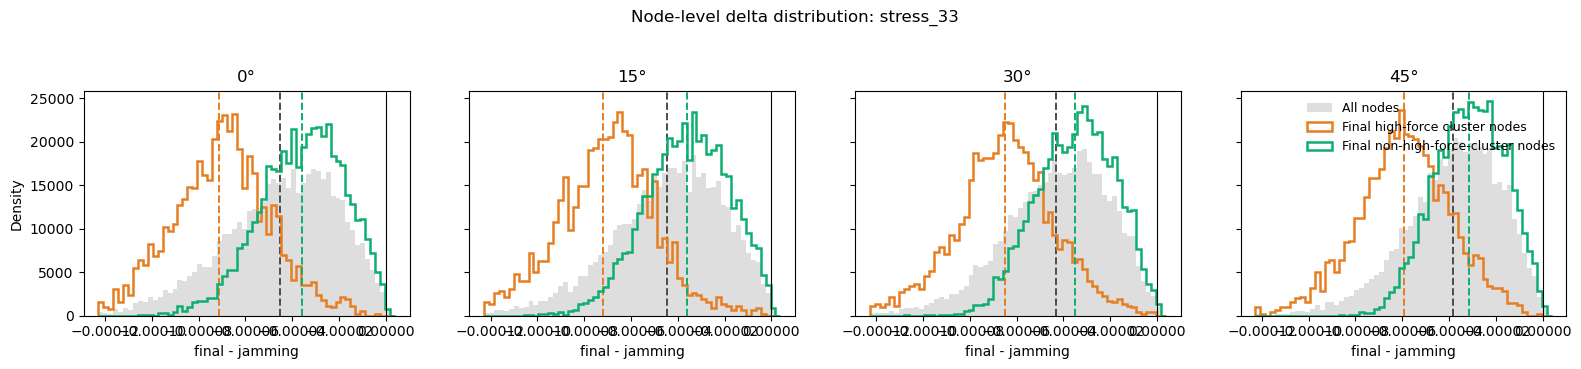

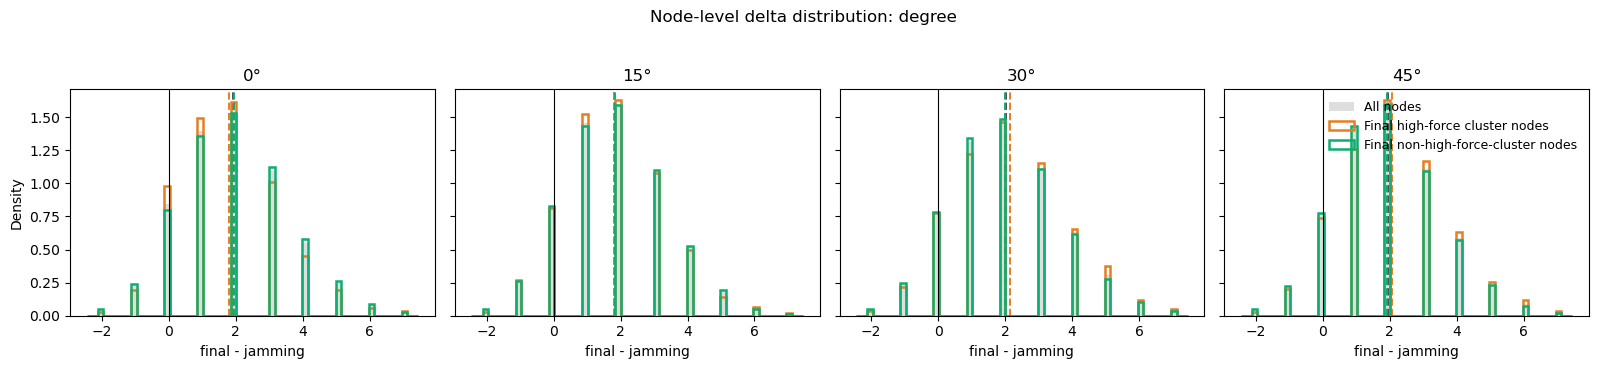

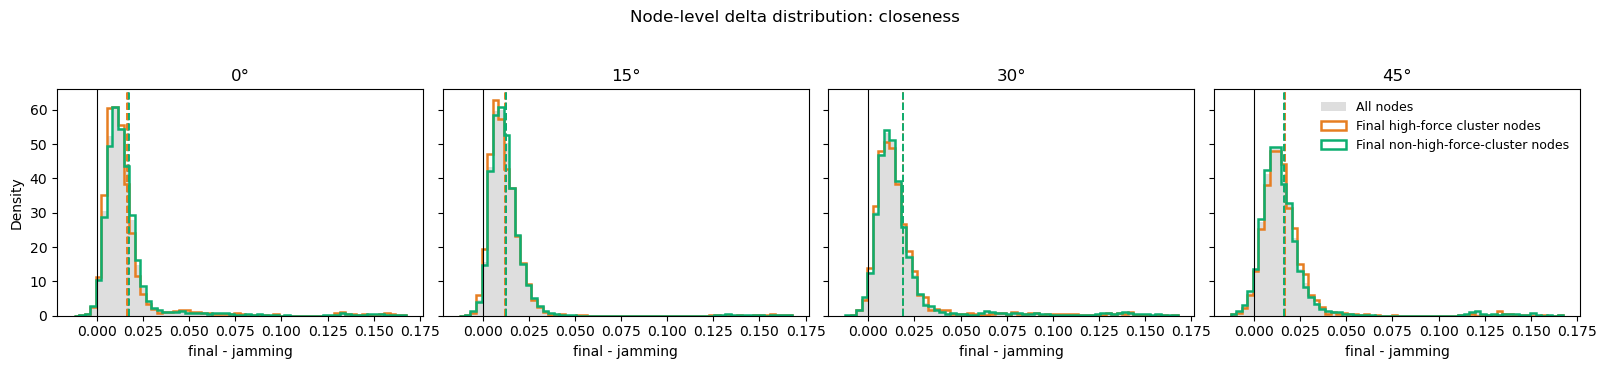

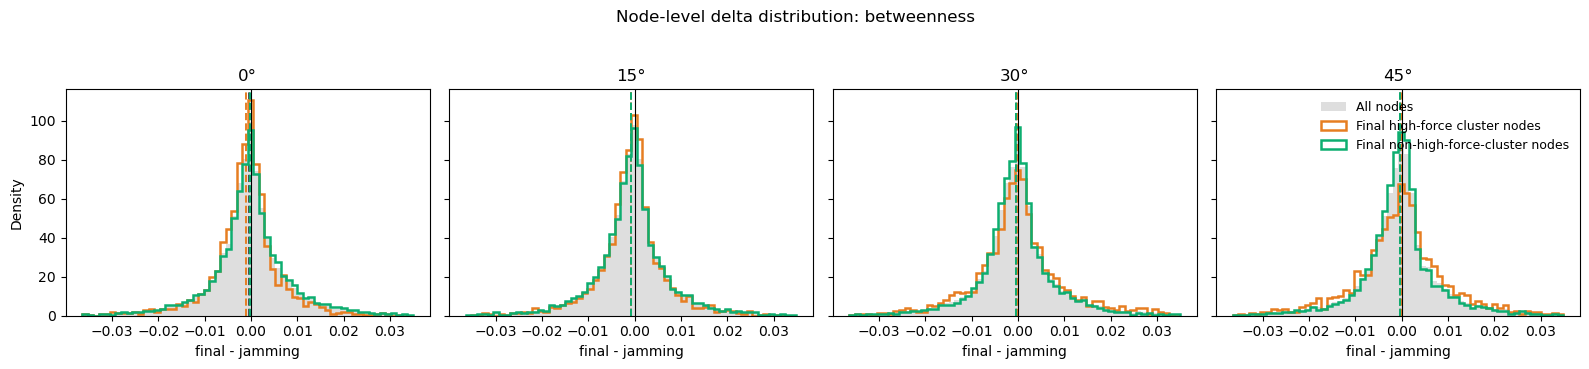

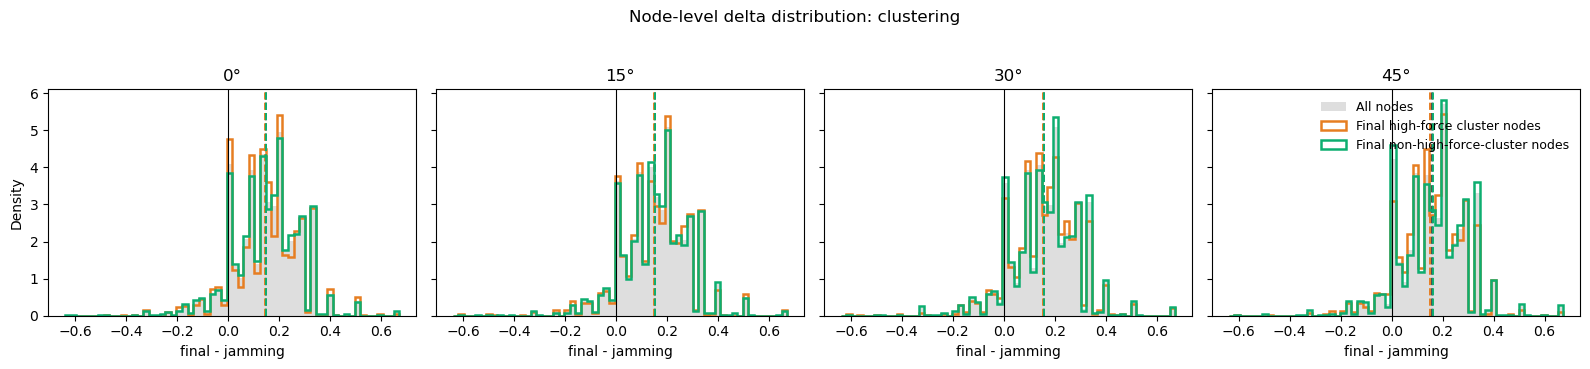

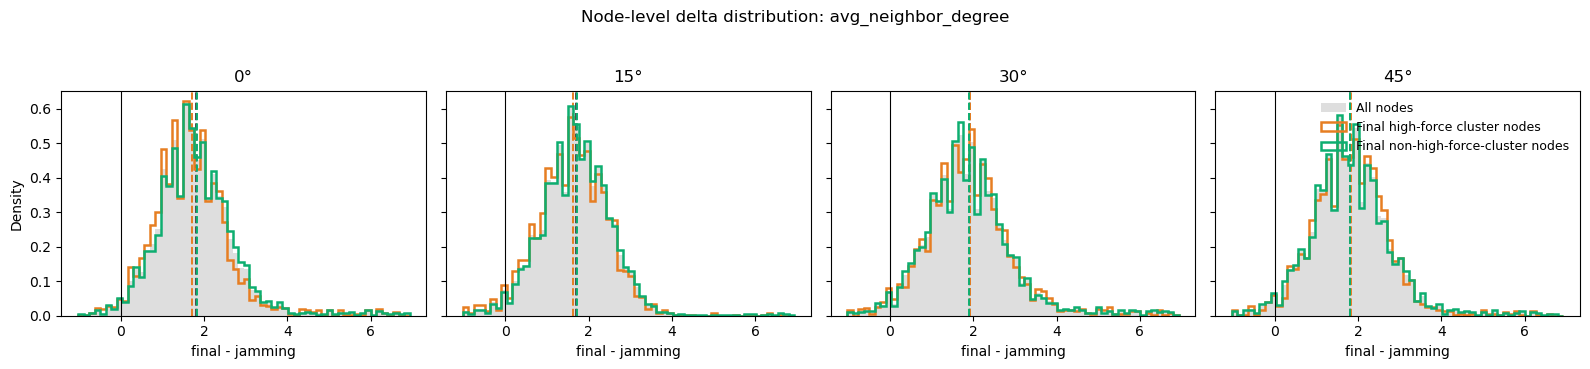

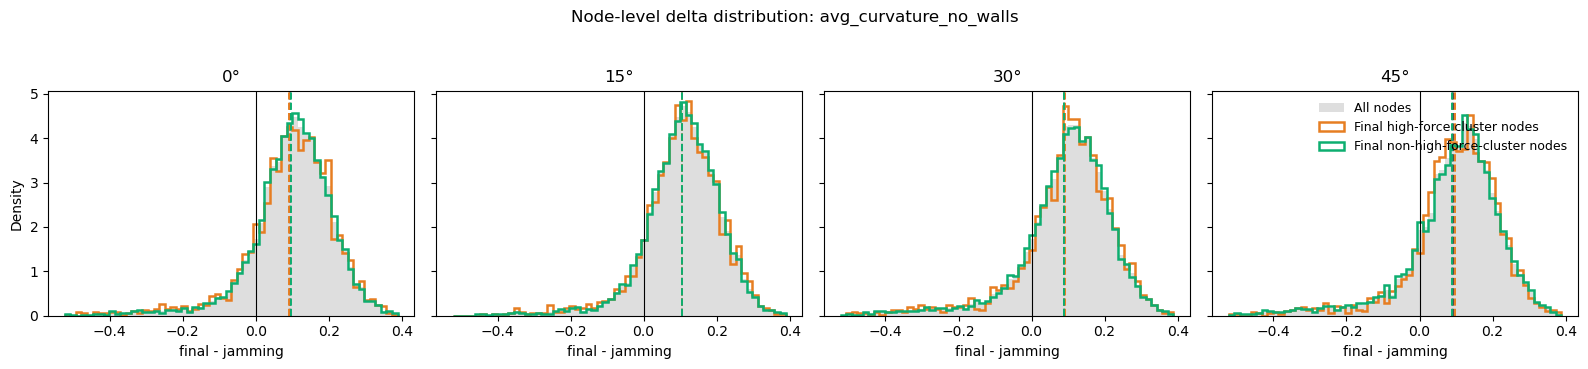

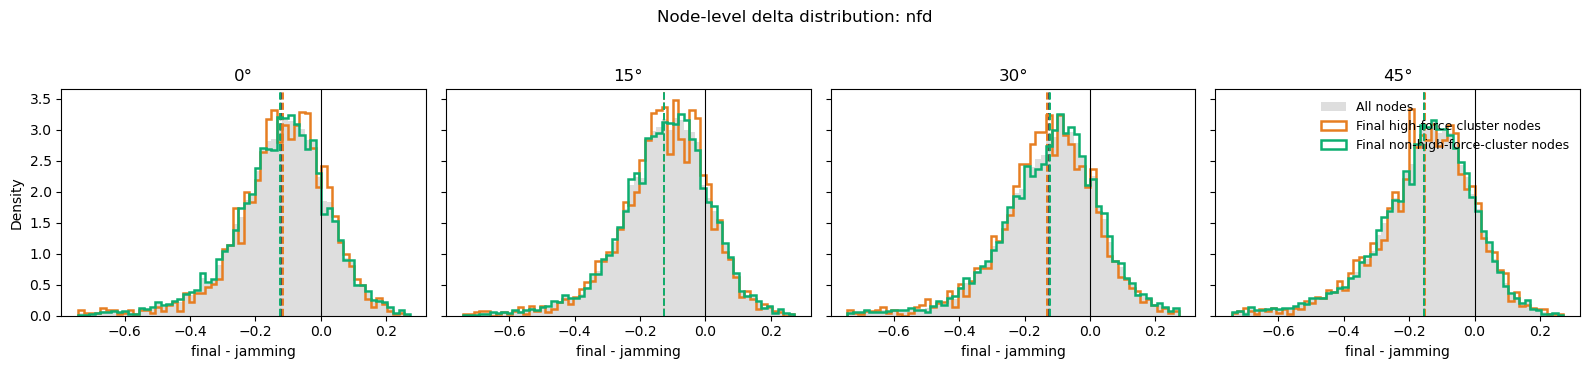

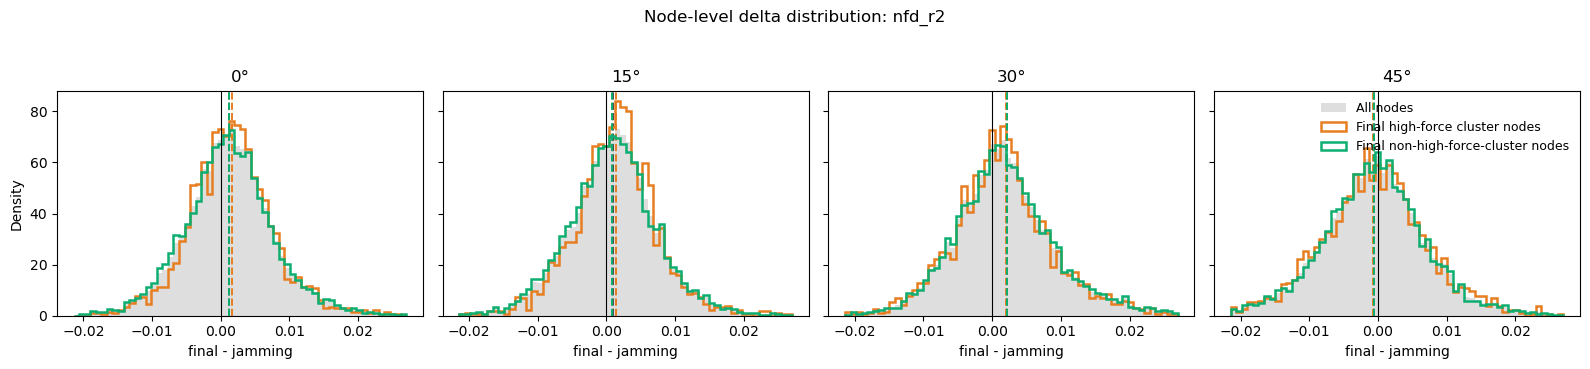

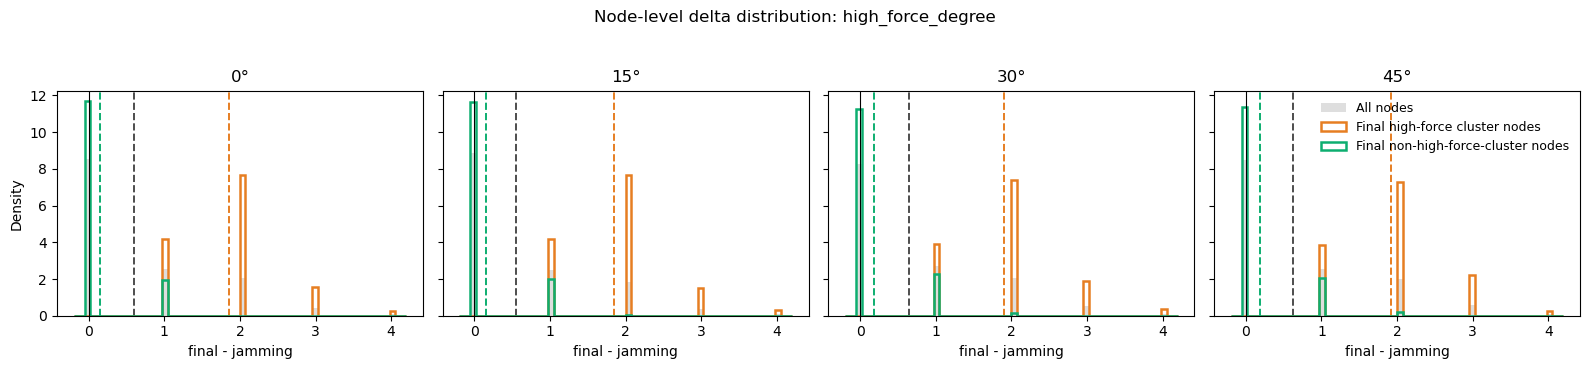

In [6]:
def plot_delta_histograms(feature, bins=60, save=True):
    data = node_changes.query("feature == @feature and geometry in @GEOM_ORDER").copy()
    data = data[np.isfinite(data["delta_final_minus_jamming"])]
    if data.empty:
        raise ValueError(f"No delta data found for feature: {feature}")

    x_min = data["delta_final_minus_jamming"].quantile(0.005)
    x_max = data["delta_final_minus_jamming"].quantile(0.995)
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        x_min = data["delta_final_minus_jamming"].min()
        x_max = data["delta_final_minus_jamming"].max()
    pad = 0.05 * (x_max - x_min) if x_max > x_min else 1.0
    x_range = (x_min - pad, x_max + pad)

    fig, axes = plt.subplots(1, len(GEOM_ORDER), figsize=(16, 3.5), sharex=True, sharey=True)
    for ax, geom, label in zip(axes, GEOM_ORDER, GEOM_LABELS):
        geom_data = data[data["geometry"] == geom]
        all_vals = geom_data["delta_final_minus_jamming"].to_numpy()
        ax.hist(
            all_vals,
            bins=bins,
            range=x_range,
            density=True,
            histtype="stepfilled",
            color=GROUP_COLORS["all"],
            alpha=0.18,
            label=GROUP_LABELS["all"],
        )
        ax.axvline(np.nanmean(all_vals), color=GROUP_COLORS["all"], linestyle="--", linewidth=1.4)

        for group in ["final_hf_cluster", "final_non_hf_cluster"]:
            vals = geom_data.loc[geom_data["final_cluster_group"] == group, "delta_final_minus_jamming"].to_numpy()
            ax.hist(
                vals,
                bins=bins,
                range=x_range,
                density=True,
                histtype="step",
                color=GROUP_COLORS[group],
                linewidth=1.8,
                label=GROUP_LABELS[group],
            )
            ax.axvline(np.nanmean(vals), color=GROUP_COLORS[group], linestyle="--", linewidth=1.4)

        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_title(label)
        ax.set_xlabel("final - jamming")
        ax.grid(False)
    axes[0].set_ylabel("Density")
    axes[-1].legend(frameon=False, fontsize=9, loc="upper right")
    fig.suptitle(f"Node-level delta distribution: {feature}", y=1.04)
    fig.tight_layout()
    if save:
        fig.savefig(PLOT_DIR / f"delta_hist_{feature}_by_final_cluster_group.png", dpi=250, bbox_inches="tight")
    return fig, axes

for feature in FEATURES:
    plot_delta_histograms(feature)
    plt.show()

## 6. Node-Level Tracking Scatter for All Geometries

Each panel tracks the same particles from jamming to final state. Orange points are nodes that belong to high-force clusters in the final state; green points are final non-high-force-cluster nodes. All panels share one x-range determined by jamming values and one y-range determined by final values. The black line is the `y = x` reference.

In [ ]:
TRACK_FEATURE = "stress_vm"
TRACK_SIM_IDX = 0  # set to None to pool all simulations; 0 keeps the plot readable

tracked = node_changes.query("feature == @TRACK_FEATURE and geometry in @GEOM_ORDER").copy()
if TRACK_SIM_IDX is not None:
    tracked = tracked[tracked["sim_idx"] == TRACK_SIM_IDX]

tracked[["geometry", "sim_idx", "node_id", "final_cluster_group", "jamming", "final", "delta_final_minus_jamming"]].head()

In [ ]:
def plot_tracking_scatter(feature=TRACK_FEATURE, sim_idx=TRACK_SIM_IDX, save=True):
    tracked = node_changes.query("feature == @feature and geometry in @GEOM_ORDER").copy()
    if sim_idx is not None:
        tracked = tracked[tracked["sim_idx"] == sim_idx]
    tracked = tracked[np.isfinite(tracked["jamming"]) & np.isfinite(tracked["final"])]
    if tracked.empty:
        raise ValueError(f"No tracking data found for {feature}, sim_idx={sim_idx}")

    x_min, x_max = tracked["jamming"].min(), tracked["jamming"].max()
    y_min, y_max = tracked["final"].min(), tracked["final"].max()
    x_pad = 0.05 * (x_max - x_min) if x_max > x_min else 1.0
    y_pad = 0.05 * (y_max - y_min) if y_max > y_min else 1.0
    x_lims = [x_min - x_pad, x_max + x_pad]
    y_lims = [y_min - y_pad, y_max + y_pad]
    diag_lims = [min(x_lims[0], y_lims[0]), max(x_lims[1], y_lims[1])]

    fig, axes = plt.subplots(2, 2, figsize=(8, 8), sharex=True, sharey=True)
    axes = axes.ravel()
    for ax, geom, label in zip(axes, GEOM_ORDER, GEOM_LABELS):
        geom_data = tracked[tracked["geometry"] == geom]
        for group in ["final_non_hf_cluster", "final_hf_cluster"]:
            sub = geom_data[geom_data["final_cluster_group"] == group]
            ax.scatter(
                sub["jamming"],
                sub["final"],
                s=8,
                alpha=0.45,
                color=GROUP_COLORS[group],
                label=GROUP_LABELS[group],
                rasterized=True,
            )
        ax.plot(diag_lims, diag_lims, color="black", linewidth=0.8)
        ax.set_xlim(x_lims)
        ax.set_ylim(y_lims)
        title = f"{label}"
        if sim_idx is not None:
            title += f" sim {sim_idx}"
        ax.set_title(title)
        ax.grid(False)

    for ax in axes[::2]:
        ax.set_ylabel(f"final {feature}")
    for ax in axes[2:]:
        ax.set_xlabel(f"jamming {feature}")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, frameon=False, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(f"Node tracking: {feature}", y=1.07)
    fig.tight_layout()
    if save:
        suffix = "all_sims" if sim_idx is None else f"sim{sim_idx:03d}"
        fig.savefig(PLOT_DIR / f"tracking_scatter_{feature}_{suffix}_by_final_cluster_group.png", dpi=250, bbox_inches="tight")
    return fig, axes

plot_tracking_scatter()
plt.show()

## 7. Binned Node-Tracking Matrix by Geometry and Final Cluster Group

This view bins particles by `(jamming value, final value)` using all simulations by default. Each figure is one property. Rows are geometries and columns are final high-force cluster nodes, final non-high-force-cluster nodes, and all nodes.

For `VALUE_MODE = "count"`, each column has its own shared color scale across the four geometry rows. For `VALUE_MODE = "fraction"`, all panels share one color scale so fractions are directly comparable.

Available features:
['avg_curvature_no_walls', 'avg_curvature_with_walls', 'avg_neighbor_degree', 'avg_neighbor_degree_with_walls', 'betweenness', 'betweenness_with_walls', 'closeness', 'closeness_with_walls', 'clustering', 'clustering_with_walls', 'degree', 'degree_with_walls', 'fiedler', 'fiedler_with_walls', 'high_force_degree', 'nfd', 'nfd_r2', 'principal_eigenvector', 'principal_eigenvector_with_walls', 'stress_11', 'stress_12', 'stress_13', 'stress_22', 'stress_23', 'stress_33', 'stress_hydro', 'stress_vm', 'x', 'y', 'z']


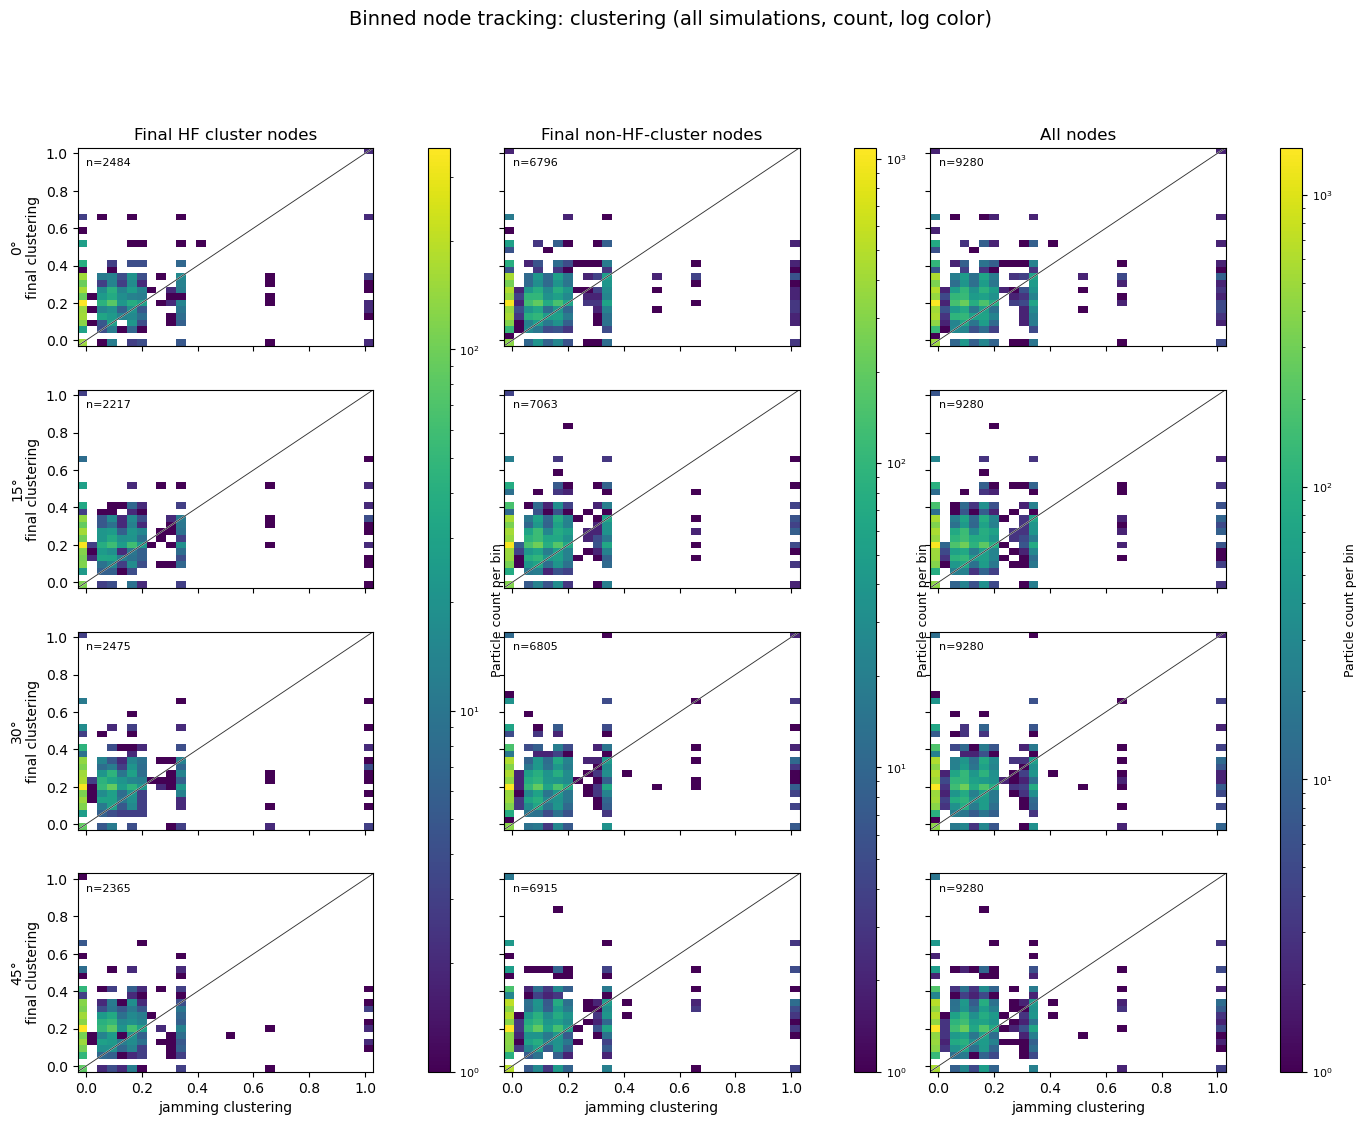

In [10]:
# ---- Choose the property and bin-plot options here ----
# Must be one of the values in node_changes["feature"].unique().
# Common options: "stress_vm", "stress_hydro", "stress_33", "degree",
# "closeness", "betweenness", "clustering", "avg_neighbor_degree",
# "avg_curvature_no_walls", "nfd", "nfd_r2", "high_force_degree".
BIN_FEATURE = "clustering"
BIN_SIM_IDX = None  # None pools all simulations in each geometry
BIN_COUNT = 30
VALUE_MODE = "count"  # "count" or "fraction"
LOG_COLOR = True      # only applied to count mode

print("Available features:")
print(sorted(node_changes["feature"].unique()))

BIN_GROUPS = ["final_hf_cluster", "final_non_hf_cluster", "all"]
BIN_GROUP_TITLES = {
    "final_hf_cluster": "Final HF cluster nodes",
    "final_non_hf_cluster": "Final non-HF-cluster nodes",
    "all": "All nodes",
}


def _shared_xy_edges(data, bins=55):
    x = data["jamming"].to_numpy()
    y = data["final"].to_numpy()
    x_min, x_max = np.nanmin(x), np.nanmax(x)
    y_min, y_max = np.nanmin(y), np.nanmax(y)
    x_pad = 0.03 * (x_max - x_min) if x_max > x_min else 1.0
    y_pad = 0.03 * (y_max - y_min) if y_max > y_min else 1.0
    return (
        np.linspace(x_min - x_pad, x_max + x_pad, bins + 1),
        np.linspace(y_min - y_pad, y_max + y_pad, bins + 1),
    )


def _hist_for_group(data, geom, group, x_edges, y_edges, value_mode):
    sub = data[data["geometry"] == geom]
    if group != "all":
        sub = sub[sub["final_cluster_group"] == group]

    H, _, _ = np.histogram2d(sub["jamming"], sub["final"], bins=[x_edges, y_edges])
    if value_mode == "fraction":
        denom = H.sum()
        if denom > 0:
            H = H / denom
    return H


def _make_norms(histograms, value_mode="count", log_color=True):
    norms = {}
    if value_mode == "fraction":
        max_val = max(float(H.max()) for H in histograms.values())
        shared_norm = plt.Normalize(vmin=0, vmax=max_val if max_val > 0 else 1)
        return {group: shared_norm for group in BIN_GROUPS}

    for group in BIN_GROUPS:
        positives = np.concatenate([
            histograms[(geom, group)][histograms[(geom, group)] > 0].ravel()
            for geom in GEOM_ORDER
            if np.any(histograms[(geom, group)] > 0)
        ])
        if positives.size == 0:
            norms[group] = plt.Normalize(vmin=0, vmax=1)
        elif log_color:
            norms[group] = LogNorm(vmin=max(1, float(positives.min())), vmax=float(positives.max()))
        else:
            norms[group] = plt.Normalize(vmin=0, vmax=float(positives.max()))
    return norms


def plot_binned_tracking_matrix(
    feature=BIN_FEATURE,
    sim_idx=BIN_SIM_IDX,
    bins=BIN_COUNT,
    value_mode=VALUE_MODE,
    log_color=LOG_COLOR,
    save=True,
):
    if value_mode not in {"count", "fraction"}:
        raise ValueError("value_mode must be 'count' or 'fraction'")

    data = node_changes.query("feature == @feature and geometry in @GEOM_ORDER").copy()
    if sim_idx is not None:
        data = data[data["sim_idx"] == sim_idx]
    data = data[np.isfinite(data["jamming"]) & np.isfinite(data["final"])]
    if data.empty:
        raise ValueError(f"No tracking data for feature={feature}, sim_idx={sim_idx}")

    x_edges, y_edges = _shared_xy_edges(data, bins=bins)
    diag_lims = [min(x_edges[0], y_edges[0]), max(x_edges[-1], y_edges[-1])]

    histograms = {
        (geom, group): _hist_for_group(data, geom, group, x_edges, y_edges, value_mode)
        for geom in GEOM_ORDER
        for group in BIN_GROUPS
    }
    norms = _make_norms(histograms, value_mode=value_mode, log_color=log_color)

    import copy as _copy
    cmap = _copy.copy(plt.get_cmap("viridis"))
    cmap.set_bad("white")

    # Data columns alternate with narrow colorbar columns. Count mode uses one
    # colorbar per group column; fraction mode uses one shared colorbar.
    if value_mode == "count":
        width_ratios = [1, 0.075, 1, 0.075, 1, 0.075]
        fig = plt.figure(figsize=(15.8, 12.0))
        gs = fig.add_gridspec(
            nrows=len(GEOM_ORDER),
            ncols=6,
            width_ratios=width_ratios,
            wspace=0.34,
            hspace=0.22,
        )
        data_col_for_group = {"final_hf_cluster": 0, "final_non_hf_cluster": 2, "all": 4}
        cbar_col_for_group = {"final_hf_cluster": 1, "final_non_hf_cluster": 3, "all": 5}
    else:
        width_ratios = [1, 1, 1, 0.075]
        fig = plt.figure(figsize=(14.2, 12.0))
        gs = fig.add_gridspec(
            nrows=len(GEOM_ORDER),
            ncols=4,
            width_ratios=width_ratios,
            wspace=0.28,
            hspace=0.22,
        )
        data_col_for_group = {"final_hf_cluster": 0, "final_non_hf_cluster": 1, "all": 2}

    meshes = {}
    axes = {}
    for row, (geom, geom_label) in enumerate(zip(GEOM_ORDER, GEOM_LABELS)):
        for group in BIN_GROUPS:
            col = data_col_for_group[group]
            ax = fig.add_subplot(gs[row, col])
            axes[(geom, group)] = ax

            H = histograms[(geom, group)]
            values = np.ma.masked_where(H.T <= 0, H.T)
            mesh = ax.pcolormesh(
                x_edges,
                y_edges,
                values,
                cmap=cmap,
                norm=norms[group],
                shading="auto",
            )
            meshes[group] = mesh

            ax.plot(diag_lims, diag_lims, color="white", linewidth=1.1, alpha=0.9)
            ax.plot(diag_lims, diag_lims, color="black", linewidth=0.65, alpha=0.8)
            ax.set_xlim(x_edges[0], x_edges[-1])
            ax.set_ylim(y_edges[0], y_edges[-1])
            ax.grid(False)

            if row == 0:
                ax.set_title(BIN_GROUP_TITLES[group], fontsize=12)
            if col == 0:
                ax.set_ylabel(f"{geom_label}\nfinal {feature}")
            else:
                ax.tick_params(labelleft=False)
            if row == len(GEOM_ORDER) - 1:
                ax.set_xlabel(f"jamming {feature}")
            else:
                ax.tick_params(labelbottom=False)

            count = int(H.sum()) if value_mode == "count" else int((data[(data["geometry"] == geom) & ((data["final_cluster_group"] == group) if group != "all" else True)]).shape[0])
            ax.text(
                0.03,
                0.95,
                f"n={count}",
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=8,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.72, pad=1.5),
            )

    if value_mode == "count":
        for group in BIN_GROUPS:
            cax = fig.add_subplot(gs[:, cbar_col_for_group[group]])
            cbar = fig.colorbar(meshes[group], cax=cax)
            cbar.set_label("Particle count per bin", fontsize=9, labelpad=8)
            cbar.ax.tick_params(labelsize=8)
    else:
        cax = fig.add_subplot(gs[:, 3])
        cbar = fig.colorbar(meshes["all"], cax=cax)
        cbar.set_label("Fraction of particles per bin", fontsize=9, labelpad=8)
        cbar.ax.tick_params(labelsize=8)

    sim_label = "all simulations" if sim_idx is None else f"sim {sim_idx}"
    scale_label = "log" if (log_color and value_mode == "count") else "linear"
    fig.suptitle(
        f"Binned node tracking: {feature} ({sim_label}, {value_mode}, {scale_label} color)",
        y=0.995,
        fontsize=14,
    )

    if save:
        sim_suffix = "all_sims" if sim_idx is None else f"sim{sim_idx:03d}"
        fig.savefig(
            PLOT_DIR / f"binned_tracking_matrix_{feature}_{sim_suffix}_{value_mode}.png",
            dpi=250,
            bbox_inches="tight",
        )
    return fig, axes


plot_binned_tracking_matrix()
plt.show()

## 8. Binned Tracking Matrix for Fractions

Fraction mode uses the same layout but normalizes each panel by the number of particles in that geometry/group. All panels share one color scale.

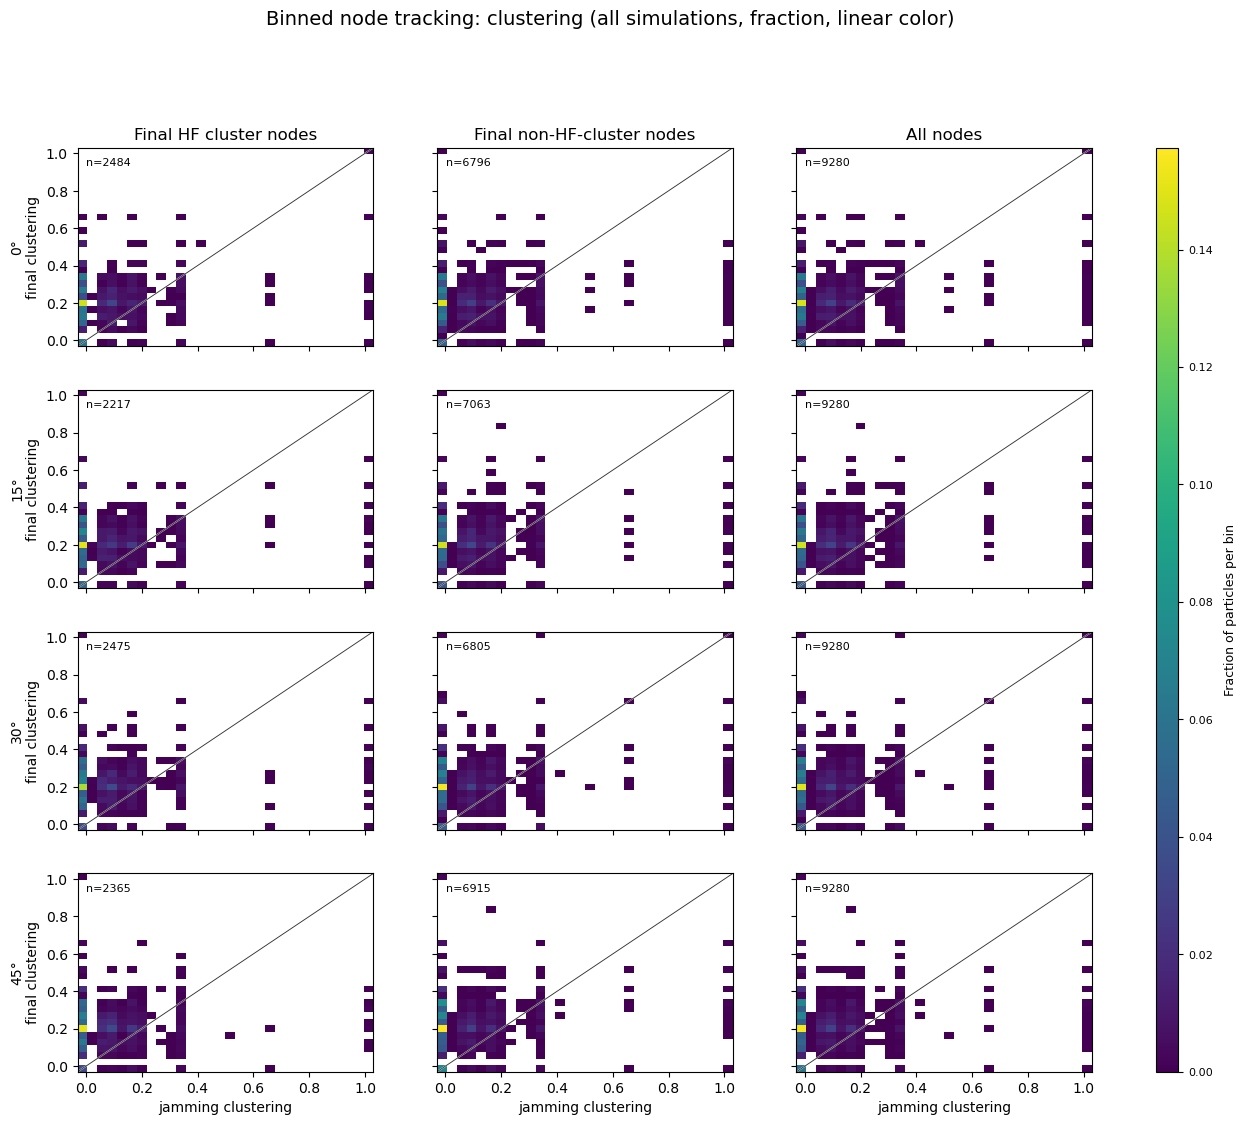

In [11]:
plot_binned_tracking_matrix(value_mode="fraction", log_color=False)
plt.show()

## 9. Loop Count Comparison Between Load Steps

This section compares saved loop metrics from `graph_features.csv` for the corrected jamming state and final load state. It does not recompute loops.

In [4]:
# Choose whether to compare loop metrics with or without wall nodes.
LOOP_WITH_WALLS = False
LOOP_TOTAL_COL = "loop_total_with_walls" if LOOP_WITH_WALLS else "loop_total"
LOOP_MEAN_COL = "loop_mean_with_walls" if LOOP_WITH_WALLS else "loop_mean"
LOOP_PREFIX_SUFFIX = "_with_walls" if LOOP_WITH_WALLS else ""

final_graph_features = pd.read_csv(FINAL_DIR / "graph_features.csv")
jamming_graph_features = pd.read_csv(JAMMING_DIR / "graph_features.csv")

loop_compare = jamming_graph_features[["geometry", "sim_idx", LOOP_TOTAL_COL, LOOP_MEAN_COL]].merge(
    final_graph_features[["geometry", "sim_idx", LOOP_TOTAL_COL, LOOP_MEAN_COL]],
    on=["geometry", "sim_idx"],
    how="inner",
    suffixes=("_jamming", "_final"),
    validate="one_to_one",
)
loop_compare["loop_total_delta_final_minus_jamming"] = (
    loop_compare[f"{LOOP_TOTAL_COL}_final"] - loop_compare[f"{LOOP_TOTAL_COL}_jamming"]
)
loop_compare["loop_mean_delta_final_minus_jamming"] = (
    loop_compare[f"{LOOP_MEAN_COL}_final"] - loop_compare[f"{LOOP_MEAN_COL}_jamming"]
)
loop_compare["loop_total_relative_delta"] = (
    loop_compare["loop_total_delta_final_minus_jamming"] / loop_compare[f"{LOOP_TOTAL_COL}_jamming"].replace(0, np.nan)
)
loop_compare.to_csv(COMPARE_DIR / "loop_count_comparison_per_sim.csv", index=False)
loop_compare.head()

,geometry,sim_idx,loop_total_jamming,loop_mean_jamming,loop_total_final,loop_mean_final,loop_total_delta_final_minus_jamming,loop_mean_delta_final_minus_jamming,loop_total_relative_delta
0,0deg,0,512,4.439453,961,3.445369,449,-0.994084,0.876953
1,0deg,1,533,4.420263,939,3.499468,406,-0.920795,0.761726
2,0deg,2,527,4.472486,946,3.484144,419,-0.988342,0.795066
3,0deg,3,553,4.419530,967,3.447777,414,-0.971753,0.748644
4,0deg,4,537,4.458101,920,3.526087,383,-0.932014,0.713222


In [5]:
loop_summary = (
    loop_compare.groupby("geometry")
    .agg(
        n_sims=("sim_idx", "size"),
        jamming_loop_total_mean=(f"{LOOP_TOTAL_COL}_jamming", "mean"),
        jamming_loop_total_stderr=(f"{LOOP_TOTAL_COL}_jamming", lambda x: x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0),
        final_loop_total_mean=(f"{LOOP_TOTAL_COL}_final", "mean"),
        final_loop_total_stderr=(f"{LOOP_TOTAL_COL}_final", lambda x: x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0),
        mean_delta_final_minus_jamming=("loop_total_delta_final_minus_jamming", "mean"),
        stderr_delta_final_minus_jamming=("loop_total_delta_final_minus_jamming", lambda x: x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0),
        jamming_loop_size_mean=(f"{LOOP_MEAN_COL}_jamming", "mean"),
        final_loop_size_mean=(f"{LOOP_MEAN_COL}_final", "mean"),
    )
    .reset_index()
)
loop_summary.to_csv(COMPARE_DIR / "loop_count_comparison_summary.csv", index=False)
loop_summary

,geometry,n_sims,jamming_loop_total_mean,jamming_loop_total_stderr,final_loop_total_mean,final_loop_total_stderr,mean_delta_final_minus_jamming,stderr_delta_final_minus_jamming,jamming_loop_size_mean,final_loop_size_mean
0,0deg,20,506.35,18.444979,941.25,3.401141,434.90,18.541972,4.518214,3.488997
1,15deg,20,525.30,6.661002,942.80,3.298804,417.50,8.407547,4.458812,3.470308
2,30deg,20,486.55,23.801755,948.05,3.358787,461.50,25.257360,4.578102,3.458901
3,45deg,20,471.00,11.951217,914.35,4.471709,443.35,13.497812,4.544694,3.476616


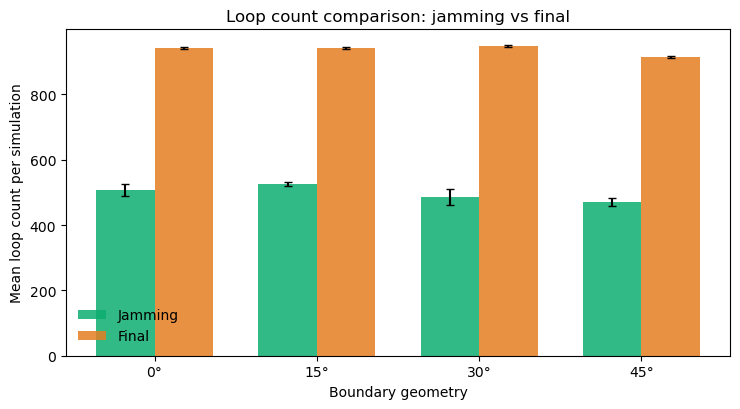

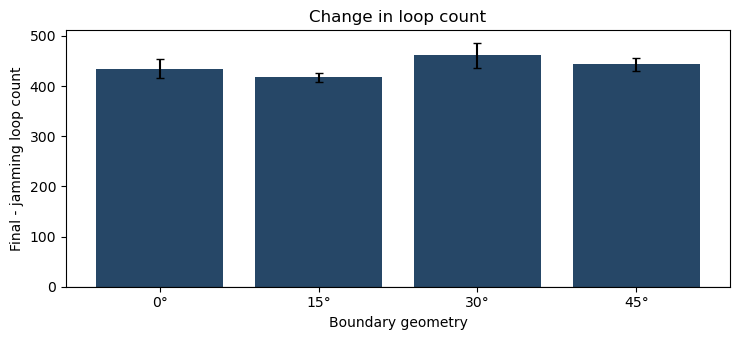

In [6]:
x = np.arange(len(GEOM_ORDER))
bar_w = 0.36
summary_plot = loop_summary.set_index("geometry").reindex(GEOM_ORDER)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar(
    x - bar_w / 2,
    summary_plot["jamming_loop_total_mean"],
    width=bar_w,
    yerr=summary_plot["jamming_loop_total_stderr"],
    capsize=3,
    color="#0DAE70",
    alpha=0.85,
    label="Jamming",
)
ax.bar(
    x + bar_w / 2,
    summary_plot["final_loop_total_mean"],
    width=bar_w,
    yerr=summary_plot["final_loop_total_stderr"],
    capsize=3,
    color="#E67E22",
    alpha=0.85,
    label="Final",
)
ax.set_xticks(x)
ax.set_xticklabels(GEOM_LABELS)
ax.set_ylabel("Mean loop count per simulation")
ax.set_xlabel("Boundary geometry")
ax.set_title("Loop count comparison: jamming vs final")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(PLOT_DIR / "loop_count_jamming_vs_final.png", dpi=250, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 3.5))
ax.axhline(0, color="black", linewidth=0.8)
ax.bar(
    x,
    summary_plot["mean_delta_final_minus_jamming"],
    yerr=summary_plot["stderr_delta_final_minus_jamming"],
    capsize=3,
    color="#00274C",
    alpha=0.85,
)
ax.set_xticks(x)
ax.set_xticklabels(GEOM_LABELS)
ax.set_ylabel("Final - jamming loop count")
ax.set_xlabel("Boundary geometry")
ax.set_title("Change in loop count")
fig.tight_layout()
fig.savefig(PLOT_DIR / "loop_count_delta_final_minus_jamming.png", dpi=250, bbox_inches="tight")
plt.show()

In [7]:
# Optional: compare loop-size composition by load step.
loop_size_cols = []
for size in range(3, 9):
    col = f"loop_{size}{LOOP_PREFIX_SUFFIX}"
    if col in final_graph_features.columns and col in jamming_graph_features.columns:
        loop_size_cols.append(col)

loop_size_summary_rows = []
for state, df in [("jamming", jamming_graph_features), ("final", final_graph_features)]:
    for geom, geom_df in df.groupby("geometry"):
        for col in loop_size_cols:
            loop_size_summary_rows.append({
                "state": state,
                "geometry": geom,
                "loop_size": int(col.split("_")[1]),
                "mean_count": geom_df[col].fillna(0).mean(),
                "stderr": geom_df[col].fillna(0).std(ddof=1) / np.sqrt(len(geom_df)) if len(geom_df) > 1 else 0.0,
            })
loop_size_summary = pd.DataFrame(loop_size_summary_rows)
loop_size_summary.to_csv(COMPARE_DIR / "loop_size_count_comparison_summary.csv", index=False)
loop_size_summary.head()

,state,geometry,loop_size,mean_count,stderr
0,jamming,0deg,3,77.85,4.221670
1,jamming,0deg,4,183.50,9.415133
2,jamming,0deg,5,181.65,7.404577
3,jamming,0deg,6,54.55,1.909085
4,jamming,0deg,7,6.75,0.848761


## 10. Loop Size Distribution: Jamming vs Final

Each panel is one geometry. The bars compare the mean per-simulation count or fraction of loops of each size at jamming and final load. This uses the saved `loop_<size>` columns in `graph_features.csv`.

In [ ]:
# Choose "count" for mean number of loops per simulation, or "fraction" for loop-size composition.
LOOP_SIZE_MODE = "fraction"  # "count" or "fraction"

# Use the union of loop sizes saved in either load step.
# If a loop_<size> column is absent in one state, treat that state as zero for that size.
def _available_loop_sizes(*dfs):
    sizes = set()
    suffix = LOOP_PREFIX_SUFFIX
    for df in dfs:
        for col in df.columns:
            if not col.startswith("loop_"):
                continue
            if suffix and not col.endswith(suffix):
                continue
            if (not suffix) and col.endswith("_with_walls"):
                continue
            size_text = col.replace("loop_", "").replace(suffix, "")
            if size_text.isdigit():
                sizes.add(int(size_text))
    return sorted(sizes)

loop_sizes = _available_loop_sizes(final_graph_features, jamming_graph_features)
loop_size_cols = [f"loop_{size}{LOOP_PREFIX_SUFFIX}" for size in loop_sizes]

if not loop_size_cols:
    raise ValueError("No loop-size columns found in final or jamming graph features.")


def _loop_size_distribution(df, geom, mode="fraction"):
    geom_df = df[df["geometry"] == geom].copy()
    values_df = pd.DataFrame(index=geom_df.index)
    for col in loop_size_cols:
        values_df[col] = geom_df[col].fillna(0) if col in geom_df.columns else 0.0
    values = values_df.to_numpy(dtype=float)
    if mode == "count":
        mean_vals = values.mean(axis=0)
        stderr_vals = values.std(axis=0, ddof=1) / np.sqrt(values.shape[0]) if values.shape[0] > 1 else np.zeros(values.shape[1])
        return mean_vals, stderr_vals
    if mode == "fraction":
        totals = values.sum(axis=1, keepdims=True)
        frac = np.divide(values, totals, out=np.zeros_like(values), where=totals > 0)
        mean_vals = frac.mean(axis=0)
        stderr_vals = frac.std(axis=0, ddof=1) / np.sqrt(frac.shape[0]) if frac.shape[0] > 1 else np.zeros(frac.shape[1])
        return mean_vals, stderr_vals
    raise ValueError("mode must be 'count' or 'fraction'")

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
axes = axes.ravel()
x = np.arange(len(loop_sizes))
bar_w = 0.38

for ax, geom, geom_label in zip(axes, GEOM_ORDER, GEOM_LABELS):
    jam_mean, jam_err = _loop_size_distribution(jamming_graph_features, geom, mode=LOOP_SIZE_MODE)
    fin_mean, fin_err = _loop_size_distribution(final_graph_features, geom, mode=LOOP_SIZE_MODE)

    ax.bar(
        x - bar_w / 2,
        jam_mean,
        width=bar_w,
        yerr=jam_err,
        capsize=2.5,
        color="#0DAE70",
        alpha=0.85,
        label="Jamming",
    )
    ax.bar(
        x + bar_w / 2,
        fin_mean,
        width=bar_w,
        yerr=fin_err,
        capsize=2.5,
        color="#E67E22",
        alpha=0.85,
        label="Final",
    )
    ax.set_title(geom_label)
    ax.set_xticks(x)
    ax.set_xticklabels(loop_sizes)
    ax.grid(False)

for ax in axes[::2]:
    ax.set_ylabel("Mean count per sim" if LOOP_SIZE_MODE == "count" else "Mean fraction of loops")
for ax in axes[2:]:
    ax.set_xlabel("Loop size")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))
fig.suptitle(f"Loop size distribution: jamming vs final ({LOOP_SIZE_MODE})", y=1.06)
fig.tight_layout()
fig.savefig(PLOT_DIR / f"loop_size_distribution_jamming_vs_final_{LOOP_SIZE_MODE}.png", dpi=250, bbox_inches="tight")
plt.show()

In [ ]:
# Save the numeric loop-size distribution summary used in the plot.
loop_size_distribution_rows = []
for state, df in [("jamming", jamming_graph_features), ("final", final_graph_features)]:
    for geom in GEOM_ORDER:
        mean_vals, stderr_vals = _loop_size_distribution(df, geom, mode=LOOP_SIZE_MODE)
        for size, mean_val, stderr_val in zip(loop_sizes, mean_vals, stderr_vals):
            loop_size_distribution_rows.append({
                "state": state,
                "geometry": geom,
                "loop_size": size,
                "mode": LOOP_SIZE_MODE,
                "mean": mean_val,
                "stderr": stderr_val,
            })
loop_size_distribution_df = pd.DataFrame(loop_size_distribution_rows)
loop_size_distribution_df.to_csv(COMPARE_DIR / f"loop_size_distribution_jamming_vs_final_{LOOP_SIZE_MODE}.csv", index=False)
loop_size_distribution_df.head(12)

## 11. Zoomed Tail of Loop Size Distribution

This plot focuses on larger loops (`loop size > 8`) and rescales the y-axis using only the tail values, so rare large loops are visible.

In [ ]:
LOOP_TAIL_MIN_SIZE = 9
LOOP_TAIL_MODE = LOOP_SIZE_MODE  # use "fraction" or "count"

tail_loop_sizes = [s for s in loop_sizes if s >= LOOP_TAIL_MIN_SIZE]
if not tail_loop_sizes:
    raise ValueError(f"No loop sizes >= {LOOP_TAIL_MIN_SIZE} found.")

tail_indices = [loop_sizes.index(s) for s in tail_loop_sizes]

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
axes = axes.ravel()
x = np.arange(len(tail_loop_sizes))
bar_w = 0.38
max_tail_value = 0.0

# Precompute distributions so the y-limit uses only the zoomed tail.
tail_data = {}
for geom in GEOM_ORDER:
    jam_mean, jam_err = _loop_size_distribution(jamming_graph_features, geom, mode=LOOP_TAIL_MODE)
    fin_mean, fin_err = _loop_size_distribution(final_graph_features, geom, mode=LOOP_TAIL_MODE)
    jam_mean, jam_err = jam_mean[tail_indices], jam_err[tail_indices]
    fin_mean, fin_err = fin_mean[tail_indices], fin_err[tail_indices]
    tail_data[geom] = (jam_mean, jam_err, fin_mean, fin_err)
    max_tail_value = max(max_tail_value, np.nanmax(jam_mean + jam_err), np.nanmax(fin_mean + fin_err))

for ax, geom, geom_label in zip(axes, GEOM_ORDER, GEOM_LABELS):
    jam_mean, jam_err, fin_mean, fin_err = tail_data[geom]
    ax.bar(
        x - bar_w / 2,
        jam_mean,
        width=bar_w,
        yerr=jam_err,
        capsize=2.5,
        color="#0DAE70",
        alpha=0.85,
        label="Jamming",
    )
    ax.bar(
        x + bar_w / 2,
        fin_mean,
        width=bar_w,
        yerr=fin_err,
        capsize=2.5,
        color="#E67E22",
        alpha=0.85,
        label="Final",
    )
    ax.set_title(geom_label)
    ax.set_xticks(x)
    ax.set_xticklabels(tail_loop_sizes)
    ax.set_ylim(0, max_tail_value * 1.15 if max_tail_value > 0 else 1)
    ax.grid(False)

for ax in axes[::2]:
    ax.set_ylabel("Mean count per sim" if LOOP_TAIL_MODE == "count" else "Mean fraction of loops")
for ax in axes[2:]:
    ax.set_xlabel("Loop size")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))
fig.suptitle(f"Zoomed large-loop distribution: sizes ≥ {LOOP_TAIL_MIN_SIZE} ({LOOP_TAIL_MODE})", y=1.06)
fig.tight_layout()
fig.savefig(PLOT_DIR / f"loop_size_distribution_tail_ge{LOOP_TAIL_MIN_SIZE}_jamming_vs_final_{LOOP_TAIL_MODE}.png", dpi=250, bbox_inches="tight")
plt.show()

# Save numeric tail summary.
tail_rows = []
for state, df in [("jamming", jamming_graph_features), ("final", final_graph_features)]:
    for geom in GEOM_ORDER:
        mean_vals, stderr_vals = _loop_size_distribution(df, geom, mode=LOOP_TAIL_MODE)
        for size, idx in zip(tail_loop_sizes, tail_indices):
            tail_rows.append({
                "state": state,
                "geometry": geom,
                "loop_size": size,
                "mode": LOOP_TAIL_MODE,
                "mean": mean_vals[idx],
                "stderr": stderr_vals[idx],
            })
tail_loop_size_distribution_df = pd.DataFrame(tail_rows)
tail_loop_size_distribution_df.to_csv(
    COMPARE_DIR / f"loop_size_distribution_tail_ge{LOOP_TAIL_MIN_SIZE}_jamming_vs_final_{LOOP_TAIL_MODE}.csv",
    index=False,
)
tail_loop_size_distribution_df.head(12)

## 12. Geometry Comparison of Loop Size Distributions

This makes two distribution-style bar figures: one for jamming and one for final. Each figure compares the four geometries within the same load step.

In [ ]:
LOOP_GEOM_MODE = LOOP_SIZE_MODE  # "fraction" or "count"
LOOP_GEOM_COLORS = {
    "0deg": "#806BEA",  # purple
    "15deg": "#3395FF", # blue
    "30deg": "#56BF7C", # green
    "45deg": "#FFD21A", # yellow
}


def plot_loop_size_geometry_distribution(state, df, mode=LOOP_GEOM_MODE, min_size=None, save=True):
    sizes_to_plot = [s for s in loop_sizes if min_size is None or s >= min_size]
    if not sizes_to_plot:
        raise ValueError(f"No loop sizes found for min_size={min_size}")
    idxs = [loop_sizes.index(s) for s in sizes_to_plot]

    x = np.arange(len(sizes_to_plot))
    bar_w = min(0.18, 0.78 / len(GEOM_ORDER))
    offsets = (np.arange(len(GEOM_ORDER)) - (len(GEOM_ORDER) - 1) / 2) * bar_w

    fig, ax = plt.subplots(figsize=(max(8.0, 0.75 * len(sizes_to_plot) + 3.0), 4.8))
    max_y = 0.0
    for offset, geom, label in zip(offsets, GEOM_ORDER, GEOM_LABELS):
        mean_vals, stderr_vals = _loop_size_distribution(df, geom, mode=mode)
        mean_vals = mean_vals[idxs]
        stderr_vals = stderr_vals[idxs]
        max_y = max(max_y, float(np.nanmax(mean_vals + stderr_vals)) if len(mean_vals) else 0.0)
        ax.bar(
            x + offset,
            mean_vals,
            width=bar_w,
            yerr=stderr_vals,
            capsize=2.2,
            color=LOOP_GEOM_COLORS[geom],
            alpha=0.86,
            label=label,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(sizes_to_plot)
    ax.set_xlabel("Loop size")
    ax.set_ylabel("Mean count per sim" if mode == "count" else "Mean fraction of loops")
    title = f"Loop size distribution by geometry: {state}"
    if min_size is not None:
        title += f" (sizes ≥ {min_size})"
        ax.set_ylim(0, max_y * 1.18 if max_y > 0 else 1)
    ax.set_title(title)
    ax.legend(frameon=False, ncol=2)
    ax.grid(False)
    fig.tight_layout()
    if save:
        suffix = f"tail_ge{min_size}" if min_size is not None else "all_sizes"
        fig.savefig(PLOT_DIR / f"loop_size_distribution_geometry_{state}_{suffix}_{mode}.png", dpi=250, bbox_inches="tight")
    return fig, ax

plot_loop_size_geometry_distribution("jamming", jamming_graph_features)
plt.show()

plot_loop_size_geometry_distribution("final", final_graph_features)
plt.show()

In [ ]:
# Save numeric summaries for the two geometry-comparison figures.
loop_geom_rows = []
for state, df in [("jamming", jamming_graph_features), ("final", final_graph_features)]:
    for geom in GEOM_ORDER:
        mean_vals, stderr_vals = _loop_size_distribution(df, geom, mode=LOOP_GEOM_MODE)
        for size, mean_val, stderr_val in zip(loop_sizes, mean_vals, stderr_vals):
            loop_geom_rows.append({
                "state": state,
                "geometry": geom,
                "loop_size": size,
                "mode": LOOP_GEOM_MODE,
                "mean": mean_val,
                "stderr": stderr_val,
            })
loop_geometry_distribution_df = pd.DataFrame(loop_geom_rows)
loop_geometry_distribution_df.to_csv(
    COMPARE_DIR / f"loop_size_distribution_geometry_comparison_{LOOP_GEOM_MODE}.csv",
    index=False,
)
loop_geometry_distribution_df.head(12)

## 13. Zoomed Geometry Comparisons for Large Loops

These are distribution-style bar plots with smaller y-axis ranges, focused on large loops: final state sizes `>= 7`, and jamming state sizes `>= 9`.

In [ ]:
FINAL_GEOM_TAIL_MIN_SIZE = 6
JAMMING_GEOM_TAIL_MIN_SIZE = 9

plot_loop_size_geometry_distribution(
    "final",
    final_graph_features,
    mode=LOOP_GEOM_MODE,
    min_size=FINAL_GEOM_TAIL_MIN_SIZE,
)
plt.show()

plot_loop_size_geometry_distribution(
    "jamming",
    jamming_graph_features,
    mode=LOOP_GEOM_MODE,
    min_size=JAMMING_GEOM_TAIL_MIN_SIZE,
)
plt.show()

## 14. Property Change vs Final Compressive Hydrostatic Stress

This binned matrix plots the chosen property change (`final - jamming`) against final-state compressive hydrostatic stress (`-1 * stress_hydro_final`). Rows are geometries and columns are final high-force cluster nodes, final non-high-force-cluster nodes, and all nodes.

In [ ]:
# ---- Choose the property-change bin plot options here ----
CHANGE_FEATURE = globals().get("BIN_FEATURE", "degree")  # e.g. "stress_vm", "degree", "nfd"
CHANGE_BIN_COUNT_X = 55
CHANGE_BIN_COUNT_Y = 55
CHANGE_VALUE_MODE = "count"  # "count" or "fraction"
CHANGE_LOG_COLOR = True      # only applied to count mode

CHANGE_GROUPS = ["final_hf_cluster", "final_non_hf_cluster", "all"]
CHANGE_GROUP_TITLES = {
    "final_hf_cluster": "Final HF cluster nodes",
    "final_non_hf_cluster": "Final non-HF-cluster nodes",
    "all": "All nodes",
}


def _make_change_norms(histograms, value_mode="count", log_color=True):
    if value_mode == "fraction":
        max_val = max(float(H.max()) for H in histograms.values())
        shared_norm = plt.Normalize(vmin=0, vmax=max_val if max_val > 0 else 1)
        return {group: shared_norm for group in CHANGE_GROUPS}

    norms = {}
    for group in CHANGE_GROUPS:
        positives = np.concatenate([
            histograms[(geom, group)][histograms[(geom, group)] > 0].ravel()
            for geom in GEOM_ORDER
            if np.any(histograms[(geom, group)] > 0)
        ])
        if positives.size == 0:
            norms[group] = plt.Normalize(vmin=0, vmax=1)
        elif log_color:
            norms[group] = LogNorm(vmin=max(1, float(positives.min())), vmax=float(positives.max()))
        else:
            norms[group] = plt.Normalize(vmin=0, vmax=float(positives.max()))
    return norms



def _property_change_vs_final_hydro_table(feature):
    prop = node_changes.query("feature == @feature").copy()
    hydro = (
        node_changes.query("feature == 'stress_hydro'")
        [["geometry", "sim_idx", "node_id", "final"]]
        .rename(columns={"final": "final_stress_hydro"})
    )
    prop = prop.merge(hydro, on=["geometry", "sim_idx", "node_id"], how="left", validate="one_to_one")
    prop["final_compressive_hydro"] = -1.0 * prop["final_stress_hydro"]
    prop = prop[np.isfinite(prop["final_compressive_hydro"]) & np.isfinite(prop["delta_final_minus_jamming"])]
    if prop.empty:
        raise ValueError(f"No data for feature {feature}")
    return prop


def _shared_edges_xy(data, x_col, y_col, bins_x=55, bins_y=55):
    x_min, x_max = data[x_col].min(), data[x_col].max()
    y_min, y_max = data[y_col].min(), data[y_col].max()
    x_pad = 0.03 * (x_max - x_min) if x_max > x_min else 1.0
    y_pad = 0.03 * (y_max - y_min) if y_max > y_min else 1.0
    return (
        np.linspace(x_min - x_pad, x_max + x_pad, bins_x + 1),
        np.linspace(y_min - y_pad, y_max + y_pad, bins_y + 1),
    )


def _hist_change_hydro(data, geom, group, x_edges, y_edges, value_mode):
    sub = data[data["geometry"] == geom]
    if group != "all":
        sub = sub[sub["final_cluster_group"] == group]
    H, _, _ = np.histogram2d(
        sub["final_compressive_hydro"],
        sub["delta_final_minus_jamming"],
        bins=[x_edges, y_edges],
    )
    if value_mode == "fraction":
        denom = H.sum()
        if denom > 0:
            H = H / denom
    return H


def plot_property_change_vs_final_hydro_matrix(
    feature=CHANGE_FEATURE,
    bins_x=CHANGE_BIN_COUNT_X,
    bins_y=CHANGE_BIN_COUNT_Y,
    value_mode=CHANGE_VALUE_MODE,
    log_color=CHANGE_LOG_COLOR,
    save=True,
):
    if value_mode not in {"count", "fraction"}:
        raise ValueError("value_mode must be 'count' or 'fraction'")

    data = _property_change_vs_final_hydro_table(feature)
    x_edges, y_edges = _shared_edges_xy(
        data,
        "final_compressive_hydro",
        "delta_final_minus_jamming",
        bins_x=bins_x,
        bins_y=bins_y,
    )

    histograms = {
        (geom, group): _hist_change_hydro(data, geom, group, x_edges, y_edges, value_mode)
        for geom in GEOM_ORDER
        for group in CHANGE_GROUPS
    }
    norms = _make_change_norms(histograms, value_mode=value_mode, log_color=log_color)

    import copy as _copy
    cmap = _copy.copy(plt.get_cmap("viridis"))
    cmap.set_bad("white")

    if value_mode == "count":
        fig = plt.figure(figsize=(15.8, 12.0))
        gs = fig.add_gridspec(
            nrows=len(GEOM_ORDER),
            ncols=6,
            width_ratios=[1, 0.075, 1, 0.075, 1, 0.075],
            wspace=0.34,
            hspace=0.22,
        )
        data_col_for_group = {"final_hf_cluster": 0, "final_non_hf_cluster": 2, "all": 4}
        cbar_col_for_group = {"final_hf_cluster": 1, "final_non_hf_cluster": 3, "all": 5}
    else:
        fig = plt.figure(figsize=(14.2, 12.0))
        gs = fig.add_gridspec(
            nrows=len(GEOM_ORDER),
            ncols=4,
            width_ratios=[1, 1, 1, 0.075],
            wspace=0.28,
            hspace=0.22,
        )
        data_col_for_group = {"final_hf_cluster": 0, "final_non_hf_cluster": 1, "all": 2}

    meshes = {}
    for row, (geom, geom_label) in enumerate(zip(GEOM_ORDER, GEOM_LABELS)):
        for group in CHANGE_GROUPS:
            ax = fig.add_subplot(gs[row, data_col_for_group[group]])
            H = histograms[(geom, group)]
            values = np.ma.masked_where(H.T <= 0, H.T)
            mesh = ax.pcolormesh(
                x_edges,
                y_edges,
                values,
                cmap=cmap,
                norm=norms[group],
                shading="auto",
            )
            meshes[group] = mesh
            ax.axhline(0, color="white", linewidth=1.1, alpha=0.9)
            ax.axhline(0, color="black", linewidth=0.65, alpha=0.8)
            ax.set_xlim(x_edges[0], x_edges[-1])
            ax.set_ylim(y_edges[0], y_edges[-1])
            ax.grid(False)
            if row == 0:
                ax.set_title(CHANGE_GROUP_TITLES[group], fontsize=12)
            if data_col_for_group[group] == 0:
                ax.set_ylabel(f"{geom_label}\nΔ {feature}")
            else:
                ax.tick_params(labelleft=False)
            if row == len(GEOM_ORDER) - 1:
                ax.set_xlabel("final -stress_hydro")
            else:
                ax.tick_params(labelbottom=False)

    if value_mode == "count":
        for group in CHANGE_GROUPS:
            cax = fig.add_subplot(gs[:, cbar_col_for_group[group]])
            cbar = fig.colorbar(meshes[group], cax=cax)
            cbar.set_label("Particle count per bin", fontsize=9, labelpad=8)
            cbar.ax.tick_params(labelsize=8)
    else:
        cax = fig.add_subplot(gs[:, 3])
        cbar = fig.colorbar(meshes["all"], cax=cax)
        cbar.set_label("Fraction of particles per bin", fontsize=9, labelpad=8)
        cbar.ax.tick_params(labelsize=8)

    scale_label = "log" if (log_color and value_mode == "count") else "linear"
    fig.suptitle(
        f"Δ {feature} vs final compressive hydrostatic stress ({value_mode}, {scale_label} color)",
        y=0.995,
        fontsize=14,
    )
    if save:
        fig.savefig(
            PLOT_DIR / f"delta_{feature}_vs_final_compressive_hydro_{value_mode}.png",
            dpi=250,
            bbox_inches="tight",
        )
    return fig


plot_property_change_vs_final_hydro_matrix()
plt.show()